In [1]:
import sys
sys.path.append('..')

In [2]:
from src.model import SegmentDataset, SegmentClassifier

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import torch
import random

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

In [4]:
rfm = pd.read_csv('../data/processed/rfm_labeled.csv')
rfm.shape

(4338, 5)

In [5]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Segment
0,12346,325,1,77183.60,At-Risk
1,12347,2,7,4310.00,Champions
2,12348,75,4,1797.24,At-Risk
3,12349,18,1,1757.55,Promising
4,12350,310,1,334.40,Lost


In [6]:
X = rfm[["Recency", "Frequency", "Monetary"]].values
y = rfm["Segment"].values

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(le.classes_)
print(np.unique(y_encoded))

['At-Risk' 'Champions' 'Lost' 'Promising']
[0 1 2 3]


In [8]:
import pickle

with open('../data/processed/label_encoder.pkl', 'wb') as f:
    pickle.dump('le', f)

In [9]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in sss.split(X, y_encoded):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]


print(X_train.shape, X_test.shape)

(3470, 3) (868, 3)


In [10]:
for segment in le.classes_:
    idx = le.transform([segment])[0]
    train_pct = (y_train == idx).sum() / len(y_train) * 100
    test_pct = (y_test == idx).sum() / len(y_test) * 100
    print(f"{segment}: train {train_pct:.1f}% | test {test_pct:.1f}%")

At-Risk: train 27.5% | test 27.5%
Champions: train 16.4% | test 16.5%
Lost: train 37.4% | test 37.3%
Promising: train 18.7% | test 18.7%


In [11]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [12]:
y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

              precision    recall  f1-score   support

     At-Risk       0.94      0.97      0.96       239
   Champions       0.99      0.93      0.96       143
        Lost       0.97      0.99      0.98       324
   Promising       0.97      0.94      0.95       162

    accuracy                           0.97       868
   macro avg       0.97      0.96      0.96       868
weighted avg       0.97      0.97      0.97       868



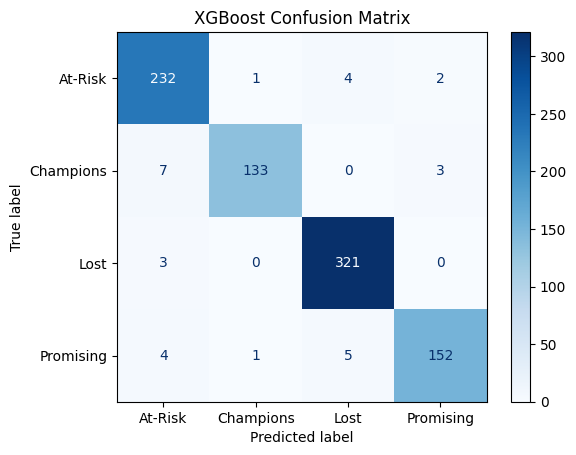

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.savefig("../outputs/figures/confusion_matrix_xgb.png", dpi=150)
plt.show()

In [14]:
from sklearn.metrics import f1_score

xgb_f1 = f1_score(y_test, y_pred_xgb, average="weighted")
print(f"XGBoost Weighted F1: {xgb_f1:.4f}")

XGBoost Weighted F1: 0.9653


In [15]:
from torch.utils.data import DataLoader

train_dataset = SegmentDataset(X_train, y_train)
test_dataset = SegmentDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [31]:
torch.manual_seed(42)

model = SegmentClassifier(
    input_dim=3,
    hidden_dim1=32,
    hidden_dim2=16,
    output_dim=4,
    dropout1=0.4,
    dropout2=0.3
)

print(model)

SegmentClassifier(
  (network): Sequential(
    (0): BatchNorm1d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Linear(in_features=3, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=16, out_features=4, bias=True)
  )
)


In [32]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss() # Needs logits
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)


In [33]:
torch.manual_seed(42)
np.random.seed(42)

epochs = 100
patience = 10
best_val_loss = float("inf")
patience_counter = 0
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            val_loss += loss.item()
    
    val_loss /= len(test_loader)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "../data/processed/best_model.pt")
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f}")

Epoch 10: Train Loss 0.6459 | Val Loss 0.5190
Epoch 20: Train Loss 0.5511 | Val Loss 0.4244
Epoch 30: Train Loss 0.5499 | Val Loss 0.4209
Early stopping at epoch 37


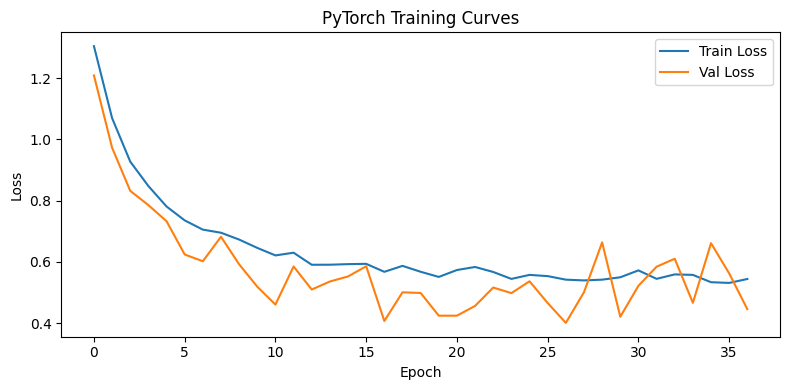

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch Training Curves")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/pytorch_training_curves.png", dpi=150)
plt.show()

In [35]:
model.load_state_dict(torch.load('../data/processed/best_model.pt'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        predicted = torch.argmax(outputs, dim=1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(y_batch.numpy())


print(classification_report(all_labels, all_preds, target_names=le.classes_))


              precision    recall  f1-score   support

     At-Risk       0.79      0.88      0.83       239
   Champions       1.00      0.78      0.87       143
        Lost       0.96      0.91      0.93       324
   Promising       0.83      0.95      0.89       162

    accuracy                           0.89       868
   macro avg       0.90      0.88      0.88       868
weighted avg       0.90      0.89      0.89       868



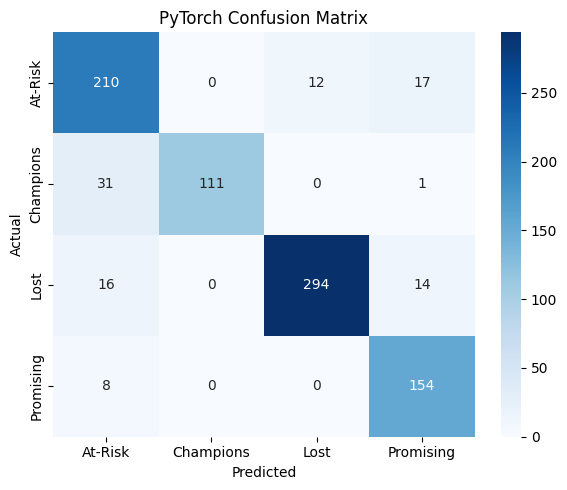

In [38]:
pytorch_f1 = f1_score(all_labels, all_preds, average='weighted')

cm_pt = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm_pt, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues'
            )

plt.title('PyTorch Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_pytorch.png', dpi=150)
plt.show()

In [40]:
comparison = pd.DataFrame({
    'Model': ['XGBoost', 'PyTorch'],
    'Weighted F1': [round(xgb_f1, 4), round(pytorch_f1, 4)],
    'Accuracy': [0.97, 0.89],
    'Champions Recall': [0.94, 0.78],
    'Lost Recall': [0.99, 0.91]

})

print(comparison)

     Model  Weighted F1  Accuracy  Champions Recall  Lost Recall
0  XGBoost       0.9653      0.97              0.94         0.99
1  PyTorch       0.8870      0.89              0.78         0.91


## Classifier Decision

XGBoost is selected as the deployment model. It outperforms 
the PyTorch feedforward network on every metric: weighted F1 
0.965 vs 0.887, accuracy 97% vs 89%, and significantly better 
recall on both Champions and Lost segments.

This is the expected result. On small tabular datasets with 
few features, gradient boosted trees consistently outperform 
neural networks. The PyTorch implementation demonstrates a 
production ML pipeline with custom Dataset class, early 
stopping, and learning rate scheduling, but XGBoost is the 
right tool for this specific problem.

XGBoost is saved for use in the intervention simulation and 
any future inference on new customers.

In [41]:
import pickle

with open('../data/processed/xgb.pkl', 'wb') as f:
    pickle.dump(xgb, f)

In [43]:
torch.save({
    'model_state_dict': model.state_dict(),
    'architecture': {
        'input_dim': 3,
        'hidden_dim1': 32,
        'hidden_dim2': 16,
        'output_dim': 4,
        'dropout1': 0.4,
        'dropout2': 0.3
    }
}, '../data/processed/pytorch_model.pt')